# Decision Tree Regression

In the previous notebooks, we built a linear regression model from scratch and applied it to the California Housing dataset.

Our model achieved a test R² of approximately 0.577.

Although this is a useful baseline, linear regression assumes that the target can be represented as a linear combination of the input features.

Real-world housing prices can contain nonlinear relationships and interactions between features.

In this notebook, we will:

1. Understand why a linear model can be limited.
2. Learn the basic idea behind decision trees.
3. Understand how a decision tree makes regression predictions.
4. Train a DecisionTreeRegressor using Scikit-learn.
5. Evaluate its performance using the same metrics as our linear model.
6. Compare the decision tree with our linear regression baseline.
7. Investigate overfitting and tree depth.

## How Does a Decision Tree Make Predictions?

A decision tree makes predictions by repeatedly splitting the data using conditions on the features.

For example:

    Is MedInc < 3?
          /    \
        Yes     No

The tree can continue splitting each resulting group until it reaches leaf nodes.

For regression, the prediction at a leaf is based on the target values of the training samples that reached that leaf, typically their mean.

The tree chooses splits that make the resulting groups as internally similar as possible.

For regression, squared error and variance are used to measure how well a split reduces the variation of the target values within the groups.

This is fundamentally different from linear regression, which learns one global equation.

## Understanding Split Quality

A regression tree wants to divide the data into groups whose target values are as similar as possible.

For each resulting group, the tree can use the mean target value as its prediction.

We can measure the quality of a group using Mean Squared Error (MSE).

A lower MSE means that the target values within the group are closer to their mean.

Therefore, a good split is one that reduces the overall squared error of the resulting groups.

This connects to the MSE we already studied in linear regression, but the optimization process is different. A decision tree does not use gradient descent to find its splits.

## Comparing Possible Splits

A decision tree does not randomly choose a condition such as `X < 5`.

It considers possible split points and measures how much each split reduces the variation in the target values.

We will manually compare two possible splits on our small dataset.

For each split, we will:

1. Divide the observations into a left and right group.
2. Calculate the MSE of each group.
3. Calculate the weighted MSE of the split.
4. Prefer the split with the lower weighted MSE.

In [1]:
import numpy as np

X = np.array([1, 2, 3, 8, 9, 10])
y = np.array([2, 3, 4, 10, 11, 12])

In [2]:
left = y[X < 5]
right = y[X >= 5]

print("Left Group:", left)
print("Right Group:", right)

Left Group: [2 3 4]
Right Group: [10 11 12]


In [3]:
left_mean = left.mean()
right_mean = right.mean()

left_mse = np.mean((left - left_mean) ** 2)
right_mse = np.mean((right - right_mean) ** 2)

print("Left MSE:", left_mse)
print("Right MSE:", right_mse)

Left MSE: 0.6666666666666666
Right MSE: 0.6666666666666666


In [4]:
weighted_mse = (
    (len(left) / len(y)) * left_mse
    + (len(right) / len(y)) * right_mse
)

print("Weighted MSE:", weighted_mse)

Weighted MSE: 0.6666666666666666


In [5]:
left = y[X < 9]
right = y[X >= 9]

print("Left Group:", left)
print("Right Group:", right)

Left Group: [ 2  3  4 10]
Right Group: [11 12]


In [6]:
left_mean = left.mean()
right_mean = right.mean()

left_mse = np.mean((left - left_mean) ** 2)
right_mse = np.mean((right - right_mean) ** 2)

print("Left MSE:", left_mse)
print("Right MSE:", right_mse)

weighted_mse = (
    (len(left) / len(y)) * left_mse
    + (len(right) / len(y)) * right_mse
)

print("Weighted MSE:", weighted_mse)

Left MSE: 9.6875
Right MSE: 0.25
Weighted MSE: 6.541666666666666


## Comparing Different Splits

We can compare different possible splits by calculating their weighted MSE.

For the split `X < 5`, the weighted MSE was approximately 0.667.

For the split `X < 9`, the weighted MSE was approximately 6.542.

The first split is better because its weighted MSE is much lower.

This demonstrates the basic decision-tree strategy:

> Choose the split that produces the most homogeneous groups, measured by the lowest weighted squared error.

Unlike linear regression, the tree does not use gradient descent to find parameters. Instead, it searches for useful splits and chooses the split that gives the greatest reduction in prediction error.

## How Does a Tree Find Possible Splits?

A decision tree needs to decide where to split the data.

For a numerical feature, the tree first considers thresholds between neighboring sorted feature values.

For example, if the feature values are:

1, 2, 3, 8, 9, 10

possible thresholds include:

1.5, 2.5, 5.5, 8.5, 9.5

For each possible threshold, the tree divides the data into two groups and calculates the weighted MSE of those groups.

The tree then selects the split with the lowest weighted MSE.

Therefore, the basic process is:

1. Generate possible thresholds.
2. Split the data.
3. Calculate the MSE of each resulting group.
4. Calculate the weighted MSE.
5. Choose the split with the lowest weighted MSE.

## Loading the Dataset

This notebook is designed to work independently from the previous notebooks.

We will recreate the same train-test split that we used for our linear regression experiments.

For a decision tree, we will use the original feature values rather than the standardized values because decision trees make decisions using thresholds and comparisons between feature values.

We will use:

- `X_train` — training features
- `X_test` — test features
- `y_train` — training target values
- `y_test` — test target values

In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


## Training a Decision Tree Regressor

We now understand the basic idea behind a regression tree, so we can use Scikit-learn's implementation.

We will use `DecisionTreeRegressor`.

Unlike our linear regression model, this model does not learn a fixed equation such as:

$$
\hat{y} = w_1x_1 + w_2x_2 + \cdots + w_8x_8 + b
$$

Instead, it learns a sequence of feature-based splits that divide the training data into smaller groups.

For regression, the default splitting criterion in Scikit-learn is squared error. The tree tries to create groups with low squared error.

In [9]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [10]:
y_pred_tree = tree_model.predict(X_test)

print(y_pred_tree[:10])

[0.414   1.203   5.00001 2.17    2.257   1.664   2.217   1.74    2.772
 5.00001]


In [11]:
print(y_test.iloc[:10].values)

[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("MAE:", mae_tree)
print("MSE:", mse_tree)
print("RMSE:", rmse_tree)
print("R²:", r2_tree)

MAE: 0.4541711942829458
MSE: 0.494255717630063
RMSE: 0.7030332265476953
R²: 0.622823312540521


## Investigating Overfitting

Our first decision tree achieved a test R² of approximately 0.623, which is better than our linear regression baseline.

However, a decision tree can become very complex if it is allowed to grow without sufficient restrictions.

A very deep tree can create very small leaf groups and may start memorizing the training data instead of learning patterns that generalize to unseen data.

This is called overfitting.

We will therefore compare the model's performance on the training and test datasets.

If the training performance is extremely good while the test performance is significantly worse, this is evidence that the tree is overfitting.

In [13]:
y_train_pred_tree = tree_model.predict(X_train)

train_mae_tree = mean_absolute_error(y_train, y_train_pred_tree)
train_mse_tree = mean_squared_error(y_train, y_train_pred_tree)
train_rmse_tree = np.sqrt(train_mse_tree)
train_r2_tree = r2_score(y_train, y_train_pred_tree)

print("Training MAE:", train_mae_tree)
print("Training MSE:", train_mse_tree)
print("Training RMSE:", train_rmse_tree)
print("Training R²:", train_r2_tree)

Training MAE: 4.217126217568424e-17
Training MSE: 9.105916214578782e-32
Training RMSE: 3.0176010694886063e-16
Training R²: 1.0


## Controlling Tree Complexity with `max_depth`

The unrestricted decision tree achieved an R² of 1.0 on the training data but only about 0.623 on the test data.

This indicates overfitting.

One way to control the complexity of a decision tree is `max_depth`.

`max_depth` specifies the maximum number of levels the tree is allowed to have.

A smaller depth produces a simpler tree, while a larger depth allows the tree to learn more detailed patterns.

We will compare different values of `max_depth` to observe how tree complexity affects training and test performance.

In [14]:
depths = [2, 3, 5, 10, 20]

results = []

for depth in depths:

    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results.append((depth, train_r2, test_r2))

for depth, train_r2, test_r2 in results:
    print(
        f"Depth: {depth:2d} | "
        f"Training R²: {train_r2:.4f} | "
        f"Test R²: {test_r2:.4f}"
    )

Depth:  2 | Training R²: 0.4520 | Test R²: 0.4244
Depth:  3 | Training R²: 0.5379 | Test R²: 0.5098
Depth:  5 | Training R²: 0.6377 | Test R²: 0.5997
Depth: 10 | Training R²: 0.8348 | Test R²: 0.6822
Depth: 20 | Training R²: 0.9957 | Test R²: 0.6261


## Observing Underfitting and Overfitting

The results show how tree complexity affects model performance.

At small depths, the tree is too simple to capture the patterns in the data. This is called underfitting.

As the depth increases, both training and test performance initially improve.

At depth 10, the test R² reaches approximately 0.682, which is better than our linear regression baseline.

However, when the depth is increased to 20, the training R² rises to approximately 0.996 while the test R² falls to approximately 0.626.

This indicates overfitting. The deeper tree is fitting the training data extremely closely but is not generalizing as well to unseen data.

Therefore, increasing model complexity does not always improve a model. We need to find a level of complexity that provides good generalization.

## Inspecting the Structure of a Decision Tree

A decision tree is made up of nodes and branches.

At each internal node, the tree asks a question about one feature.

For example:

    Is MedInc <= 3.5?

Depending on the answer, the observation moves to one of two branches.

This process continues until the observation reaches a leaf node.

At a leaf, the tree produces a regression prediction based on the training samples that reached that leaf.

We will first visualize a shallow tree so that its structure is easy to understand.

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_small = DecisionTreeRegressor(
    max_depth = 3,
    random_state=42
)

tree_small.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

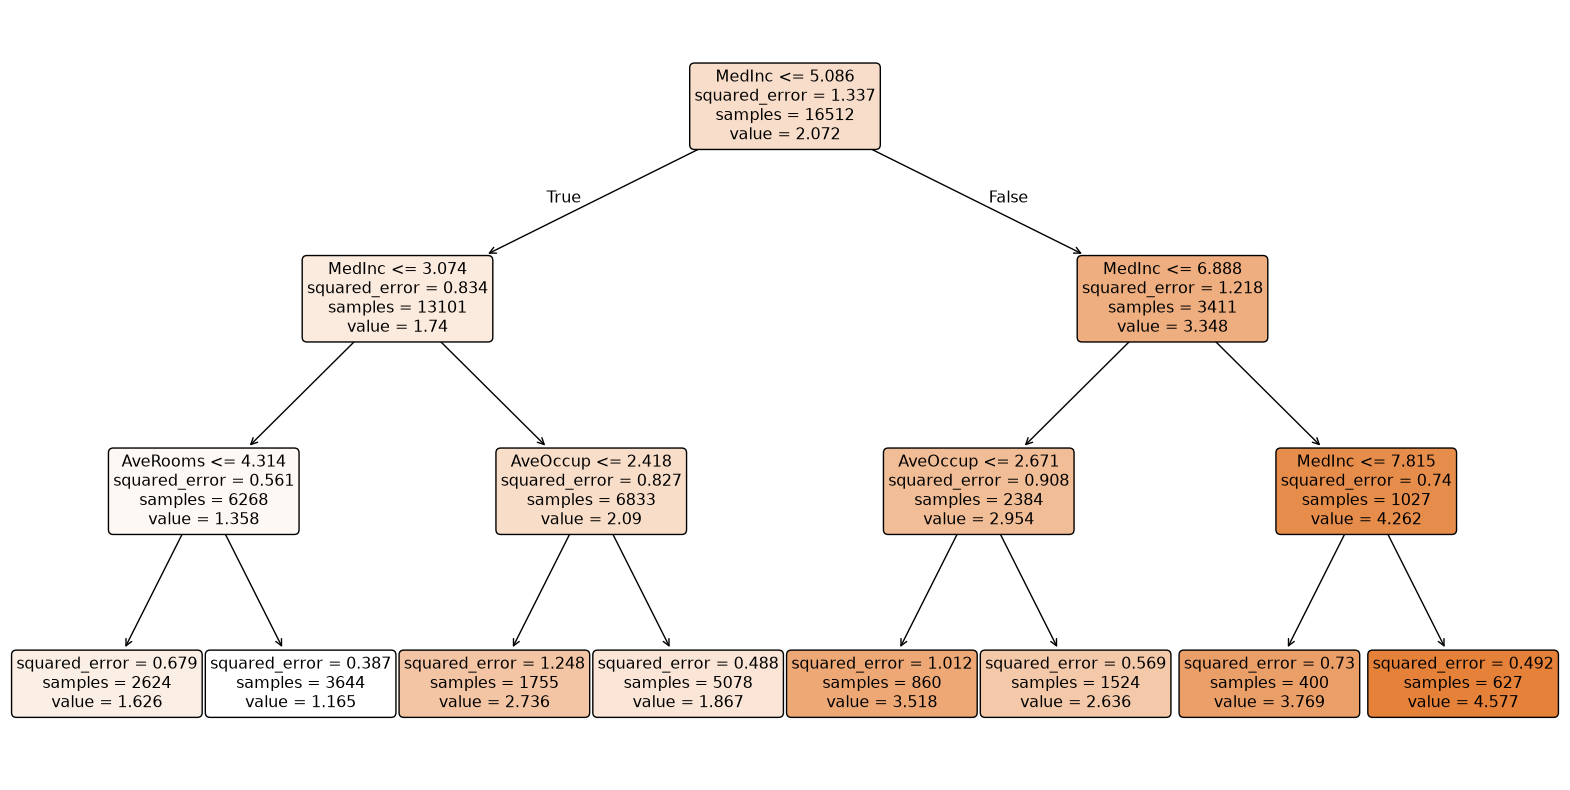

In [16]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_small,
    feature_names=X_train.columns,
    filled=True,
    rounded=True
)

plt.show()

## Reading a Decision Tree

A trained decision tree can be understood as a sequence of conditional decisions.

At each internal node, the tree contains:

- A feature and threshold used for the split.
- `samples`, which tells us how many training observations reached that node.
- `value`, which represents the mean target value of those observations.
- `squared_error`, which measures the variation of the target values at that node.

Following a path from the root to a leaf gives us a sequence of conditions.

For example:

    MedInc <= 5.086
        ↓
    MedInc <= 3.074
        ↓
    AveRooms <= 4.314
        ↓
    Leaf

The leaf contains a `value`, which becomes the prediction for observations that follow that path.

Therefore, a decision tree can be viewed as a collection of rules that divide the feature space into different regions, with each region receiving a prediction.

This is fundamentally different from linear regression, which uses one global equation for all observations.

In [17]:
first_house = X_test.iloc[0]

print(first_house)

MedInc           1.681200
HouseAge        25.000000
AveRooms         4.192201
AveBedrms        1.022284
Population    1392.000000
AveOccup         3.877437
Latitude        36.060000
Longitude     -119.010000
Name: 20046, dtype: float64


In [18]:
path = tree_small.decision_path(X_test.iloc[[0]])

print(path)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (1, 15)>
  Coords	Values
  (0, 0)	1
  (0, 1)	1
  (0, 2)	1
  (0, 3)	1


In [19]:
node_indicator = tree_small.decision_path(X_test.iloc[[0]])
leaf_id = tree_small.apply(X_test.iloc[[0]])

print("Nodes visited:", node_indicator.indices)
print("Leaf node:", leaf_id)

Nodes visited: [0 1 2 3]
Leaf node: [3]


In [20]:
tree = tree_small.tree_

for node in [0 ,1 ,2 ,3]:
    feature_index = tree.feature[node]
    threshold = tree.threshold[node]

    if (feature_index != -2):
        print(
            f"Node {node}: "
            f"{X_train.columns[feature_index]} <= {threshold:.3f}"
        )
    else:
        print(f"Node {node}: Leaf")

Node 0: MedInc <= 5.086
Node 1: MedInc <= 3.074
Node 2: AveRooms <= 4.314
Node 3: Leaf


In [21]:
leaf_id = 3

leaf_samples = X_train.index[
    tree_small.apply(X_train) == leaf_id
]

leaf_values = y_train.loc[leaf_samples]

print("Number of samples:", len(leaf_values))
print("Mean target:", leaf_values.mean())
print("Tree leaf value:", tree_small.tree_.value[leaf_id][0][0])

Number of samples: 2624
Mean target: 1.6258228849085365
Tree leaf value: 1.6258228849085399
